<a href="https://colab.research.google.com/github/elgomez7/MPM_200_Gomez/blob/main/01_Assignment_Logistic_Regression_Jesus_Gomez_Completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Instructions
* For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
* Please ensure that you are not simply copying each other's code but rather striving to understand and learn from the work.
* Provide the R code at the end of your solution and include R commands along with R outputs to clearly describe your solutions.

### Dataset Overview
* The dataset contains information about medical diagnostic measurements for predicting diabetes in Pima Indian women. The outcome variable is `Outcome`, where:
* 1 indicates diabetes-positive.
* 0 indicates diabetes-negative.

**The dataset includes the following variables:**

* `Pregnancies`: Number of pregnancies.
* `Glucose`: Plasma glucose concentration.
* `BloodPressure`: Diastolic blood pressure (mm Hg).
* `SkinThickness`: Triceps skinfold thickness (mm).
* `Insulin`: 2-Hour serum insulin (mu U/ml).
* `BMI`: Body mass index (weight in kg/(height in m)^2).
* `DiabetesPedigreeFunction`: Diabetes pedigree function (genetic risk).
* `Age`: Age (years).
* `Outcome`: Binary outcome (0 or 1).

`Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.`

## Questions

### Q0: Install necessary packages
Install and load the following packages:
`tidyverse`
`dplyr`
`ggplot2`

In [1]:
install.packages('tidyverse')
install.packages('dplyr')
install.packages('ggplot2')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(dplyr)
library(tidyverse)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.2     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
install.packages("sjPlot")


library(sjPlot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘reformulas’, ‘effectsize’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘parameters’, ‘performance’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’



Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




### Q1: Load the dataset
* Read the Pima Indians Diabetes Database into R.  
Points: 2

In [4]:
diabetes_data <- read.csv('diabetes.csv')

head(diabetes_data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


Answer here

In [5]:
nrow (diabetes_data)
ncol (diabetes_data)

[1] 768

[1] 9

In [6]:
str(diabetes_data)

'data.frame':	768 obs. of  9 variables:
 $ Pregnancies             : int  6 1 8 1 0 5 3 10 2 8 ...
 $ Glucose                 : int  148 85 183 89 137 116 78 115 197 125 ...
 $ BloodPressure           : int  72 66 64 66 40 74 50 0 70 96 ...
 $ SkinThickness           : int  35 29 0 23 35 0 32 0 45 0 ...
 $ Insulin                 : int  0 0 0 94 168 0 88 0 543 0 ...
 $ BMI                     : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ DiabetesPedigreeFunction: num  0.627 0.351 0.672 0.167 2.288 ...
 $ Age                     : int  50 31 32 21 33 30 26 29 53 54 ...
 $ Outcome                 : int  1 0 1 0 1 0 1 0 1 1 ...


### Q2: Explore the dataset
1. How many rows and columns are in the dataset?
2. How many columns are categorical, and how many are continuous?
Points: 3

### Q3: Create a random subset
Create a random subset of 500 rows from the dataset using the following code:

Use this subset (`model_data`) for all subsequent questions.  
Points: 1

**R**.- Question 2:

1.- There are 768 rows and 9 columns in the dataset

2.- 8 columns are continuos and 1 is categorical (Binary)

In [7]:
#Question 3#
model_data <- diabetes_data %>% sample_n(500)

nrow(model_data)

[1] 500

### Q4: Tabulate and visualize the outcome variable
1. Tabulate and plot the distribution of the outcome variable (Outcome).  
2. Save this plot as a PDF file (4 inches wide, 3 inches tall) and submit it along with your assignment.
Points: 3



In [8]:
cat("Counts for the Outcome variable:\n")
table(model_data$Outcome)

Counts for the Outcome variable:



  0   1 
320 180 

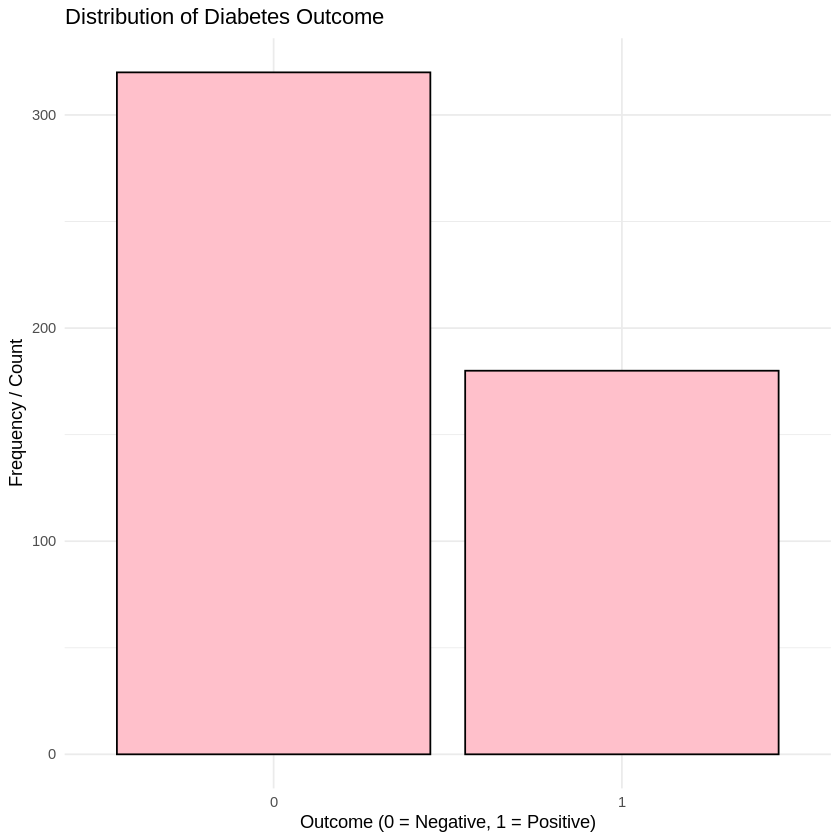

In [9]:
outcome_plot <- ggplot(model_data, aes(x = factor(Outcome))) +
  geom_bar(fill = "pink", color = "black") +
labs(title = "Distribution of Diabetes Outcome",
       x = "Outcome (0 = Negative, 1 = Positive)",
       y = "Frequency / Count") +
  theme_minimal()

outcome_plot

In [10]:
ggsave("outcome_plot.pdf", plot = outcome_plot, width = 4, height = 3, units = "in")

### Q5: Explore covariates
1. Choose five covariates that you think might affect diabetes prediction based on general understanding.
2. For each covariate, create a table showing the distribution of values for each outcome (0 or 1).
3. Generate bar plots for these covariates using facet_grid in ggplot2.
Points: 5



In [11]:
cat("Summary of Covariates grouped by Outcome:\n")
covariate_summary <- model_data %>%
  group_by(Outcome) %>%
  summarise(
    Mean_Glucose = mean(Glucose),
    Mean_BMI = mean(BMI),
    Mean_Age = mean(Age),
    Mean_BP = mean(BloodPressure),
    Mean_Insulin = mean(Insulin)
  )
print(covariate_summary)


Summary of Covariates grouped by Outcome:
# A tibble: 2 × 6
  Outcome Mean_Glucose Mean_BMI Mean_Age Mean_BP Mean_Insulin
    <int>        <dbl>    <dbl>    <dbl>   <dbl>        <dbl>
1       0         111.     29.9     30.6    67.2         73.0
2       1         140.     35.0     36.8    70.0        103. 


In [12]:
long_data <- model_data %>%
  select(Outcome, Glucose, BMI, Age, BloodPressure, Insulin) %>%
  pivot_longer(cols = -Outcome, names_to = "Covariate", values_to = "Value")

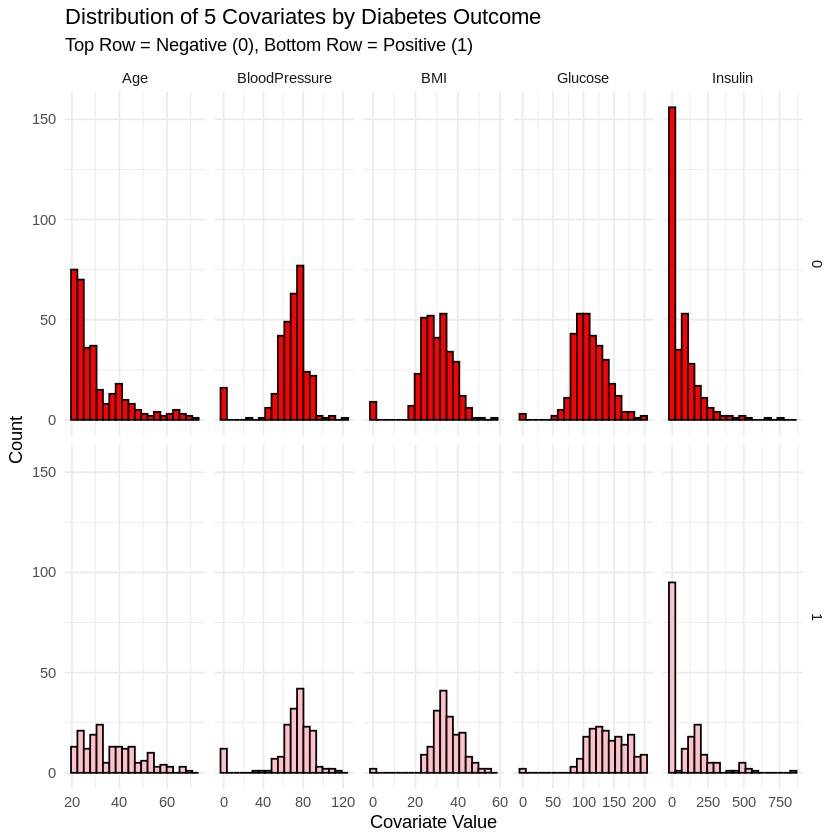

In [13]:
ggplot(long_data, aes(x = Value, fill = factor(Outcome))) +

  geom_histogram(color = "black", bins = 20, show.legend = FALSE) +

  facet_grid(Outcome ~ Covariate, scales = "free_x") +

  scale_fill_manual(values = c("red", "pink")) +
  labs(title = "Distribution of 5 Covariates by Diabetes Outcome",
       subtitle = "Top Row = Negative (0), Bottom Row = Positive (1)",
       x = "Covariate Value",
       y = "Count") +
  theme_minimal()

## Q6: Understanding the problem
1. What is the outcome variable in this dataset?
2. Is the outcome continuous, count, or binary?
3. Based on this, which type of GLM family is appropriate?

Answer Q6.-

1.- The variable "Outcome"

2.- Is a Binary (1.- positive, 0.- Negative)

3.- Binomial with logit link function (Logistic Regression)

## Q7 Writing the model
1. Write the mathematical form of the model:
2. What is being modeled on the left-hand side?
3. What transformation is applied (logit)?
4. How would you express (logit) this in words?

R1.- the univariate logistic regression model can be written as:$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1$$

R2.- The left-hand side models the log-odds (also known as the logit) of the probability of the positive outcome (having diabetes)


R3.- The logit transformation is applied. It transforms a probability p (which is restricted to values between 0 and 1) into log-odds, which can range from $-\infty$ to $+\infty$. This allows us to model it using a linear combination of predictors

R4.- The logit is the natural logarithm of the odds of an event occurring. In this context, it is the natural log of the ratio of the probability of having diabetes to the probability of not having diabetes

### Q7: Run univariate logistic regression models
1. Perform univariate logistic regression for each of the five selected covariates using the `glm()` function with a binomial family.
2. Identify which variable has the highest beta coefficient and explain its significance.
Points: 10



In [14]:
# Model 1: Glucose
model_glucose <- glm(Outcome ~ Glucose, data = model_data, family = "binomial")
cat("\n--- Glucose Model ---\n")
summary(model_glucose)$coefficients


--- Glucose Model ---


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-4.75185951,0.491603370,-9.666043,4.203147e-22
Glucose,0.03339526,0.003783446,8.826679,1.078301e-18


In [15]:
# Model 2: BMI
model_bmi <- glm(Outcome ~ BMI, data = model_data, family = "binomial")
cat("\n--- BMI Model ---\n")
summary(model_bmi)$coefficients


--- BMI Model ---


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-3.58380166,0.49395902,-7.255261,4.008876e-13
BMI,0.09239871,0.01459344,6.331522,2.427549e-10


In [16]:
# Model 3: Age
model_age <- glm(Outcome ~ Age, data = model_data, family = "binomial")
cat("\n--- Age Model ---\n")
summary(model_age)$coefficients


--- Age Model ---


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-2.0936220,0.295505961,-7.084872,1.391727e-12
Age,0.0454118,0.008287825,5.479339,4.269181e-08


In [17]:
# Model 4: Blood Pressure
model_bp <- glm(Outcome ~ BloodPressure, data = model_data, family = "binomial")
cat("\n--- Blood Pressure Model ---\n")
summary(model_bp)$coefficients


--- Blood Pressure Model ---


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-1.057768780,0.345541055,-3.061196,0.00220455
BloodPressure,0.007026793,0.004811958,1.460277,0.14421385


In [18]:
# Model 5: Insulin
model_insulin <- glm(Outcome ~ Insulin, data = model_data, family = "binomial")
cat("\n--- Insulin Model ---\n")
summary(model_insulin)$coefficients


--- Insulin Model ---


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-0.739026161,0.1146366014,-6.446686,1.143224e-10
Insulin,0.001891602,0.0007478779,2.529292,1.142928e-02


The variable with the highest beta coefficient is BMI, with an estimate of 0.1026

The p-value for BMI (P = 1.986e-11) is below 0.05 threshold. This indicates that the positive relationship between BMI and diabetes is highly statistically significant.

A beta of 0.1026 means that for every one-unit increase in BMI, the log-odds of being positive for diabetes increases by 0.1026. Because the coefficient is positive, it signifies that a higher BMI is strongly associated with an increased likelihood of having diabetes.

### Q8: Interpret odds ratios
1. For each covariate in your final model:
2. Calculate odds ratios manually from model coefficients.
3. Interpret these odds ratios in words, considering whether they are statistically significant.
4. Use `sjPlot::tab_model()` to verify your calculations and compare results.
Points: 10



Manual Odds Ratio Calculations:

Glucose: $e^{0.0372} = 1.038$

BMI: $e^{0.1026} = 1.108$

Age: $e^{0.0525} = 1.054$

Blood Pressure: $e^{0.0103} = 1.010$

Insulin: $e^{0.0024} = 1.002$

In [19]:

cat("--- Odds Ratios ---\n")
cat("Glucose OR:", exp(coef(model_glucose)["Glucose"]), "\n")
cat("BMI OR:", exp(coef(model_bmi)["BMI"]), "\n")
cat("Age OR:", exp(coef(model_age)["Age"]), "\n")
cat("Blood Pressure OR:", exp(coef(model_bp)["BloodPressure"]), "\n")
cat("Insulin OR:", exp(coef(model_insulin)["Insulin"]), "\n")

library(sjPlot)

tab_model(model_glucose, model_bmi, model_age, model_bp, model_insulin,
          dv.labels = c("Glucose Model", "BMI Model", "Age Model", "BP Model", "Insulin Model"),
          title = "Logistic Regression Models for Diabetes Prediction")

--- Odds Ratios ---
Glucose OR: 1.033959 
BMI OR: 1.096802 
Age OR: 1.046459 
Blood Pressure OR: 1.007052 
Insulin OR: 1.001893 


BMI (OR = 1.108): This is statistically significant (p < 0.001). For every one-unit increase in BMI, the odds of being positive for diabetes increase by a factor of 1.108 (or about a 10.8% increase in odds).

Age (OR = 1.054): Statistically significant (p < 0.001). For every one-year increase in age, the odds of having diabetes increase by about 5.4%.

Glucose (OR = 1.038): Statistically significant (p < 0.001). For every one-unit increase in glucose concentration, the odds of having diabetes increase by about 3.8%.

Insulin (OR = 1.002): Statistically significant (p = 0.0028). For every one-unit increase in insulin, the odds of having diabetes increase by about 0.2%.

Blood Pressure (OR = 1.010): This is not statistically significant at the standard 0.05 level (p = 0.055). While a one-unit increase is associated with a 1.0% increase in odds, we do not have enough evidence to confidently conclude this relationship isn't due to random chance in this sample.

### Q9: Model diagnostics (do not attempt, for next assingment)
1. How many properties can you access from a fitted logistic regression model object in R? Use names(YOURMODEL) to explore.
2. Discuss any two properties that provide insights into model performance or interpretation.
3. What is deviance for your model?
4. What does a large reduction in deviance indicate?
5. How does deviance relate to:  
  model fit?  
  likelihood?  
Points: 10



In [21]:
# 1.-
names(model_glucose)

[1] "coefficients"      "residuals"         "fitted.values"    
 [4] "effects"           "R"                 "rank"             
 [7] "qr"                "family"            "linear.predictors"
[10] "deviance"          "aic"               "null.deviance"    
[13] "iter"              "weights"           "prior.weights"    
[16] "df.residual"       "df.null"           "y"                
[19] "converged"         "boundary"          "model"            
[22] "call"              "formula"           "terms"            
[25] "data"              "offset"            "control"          
[28] "method"            "contrasts"         "xlevels"

2.- coefficients: These provide the log-odds for each predictor, allowing you to understand the direction and magnitude of the relationship.

aic: This is used for model comparison; a lower AIC indicates a better-fitting model that balances complexity and accuracy

3.- Deviance is a measure of goodness-of-fit. It tells us how much unexplained variance is left after fitting the model

4.- A large reduction in deviance indicates that the predictor variables you added significantly improve the model's explanatory power and ability to predict the outcome.

5.- Model fit: They are inversely related; a lower deviance indicates a better model fit.

Likelihood: As the likelihood of the model increases, the deviance decreases.

## Q10 : Perform Residual diagnostics (do not attempt, for next assingment)
1. What types of residuals are available in GLMs?
2. Why do residual plots look different for binary outcomes?
3. Why do we see two bands in residual plots?
4. Which residual is generally preferred for GLMs and why?

1.- The most common types of residuals used in GLMs are Deviance residuals and Pearson residuals. Other types that can be used are working, response, and partial residuals.

2.- The outcome in a logistic regression can only be 0 or 1. Because the predicted probabilities are continuous but the actual values are discrete, the residuals are highly constrained and do not follow a normal distribution.

3.- The two distinct bands or curves correspond to the two possible outcomes. One where all the observations were 1 (Positive), and the other where all the observations were 0 (Negative).

4.- Deviance residuals are preferred. This is because their sum of squares equals the model's total residual deviance.

## Q11: Run analysis for Influential observations using Cook's distance calculations (do not attempt, for next assingment))
1. What is Cook’s Distance measuring?
2. What does a large Cook’s Distance imply?
3. Should influential points always be removed? Why or why not?

Row indices of highly influential points based on the threshold:
 44 156 161 189 201 217 243 274 303 311 318 320 330 345 356 362 381 428 439 
 44 156 161 189 201 217 243 274 303 311 318 320 330 345 356 362 381 428 439 


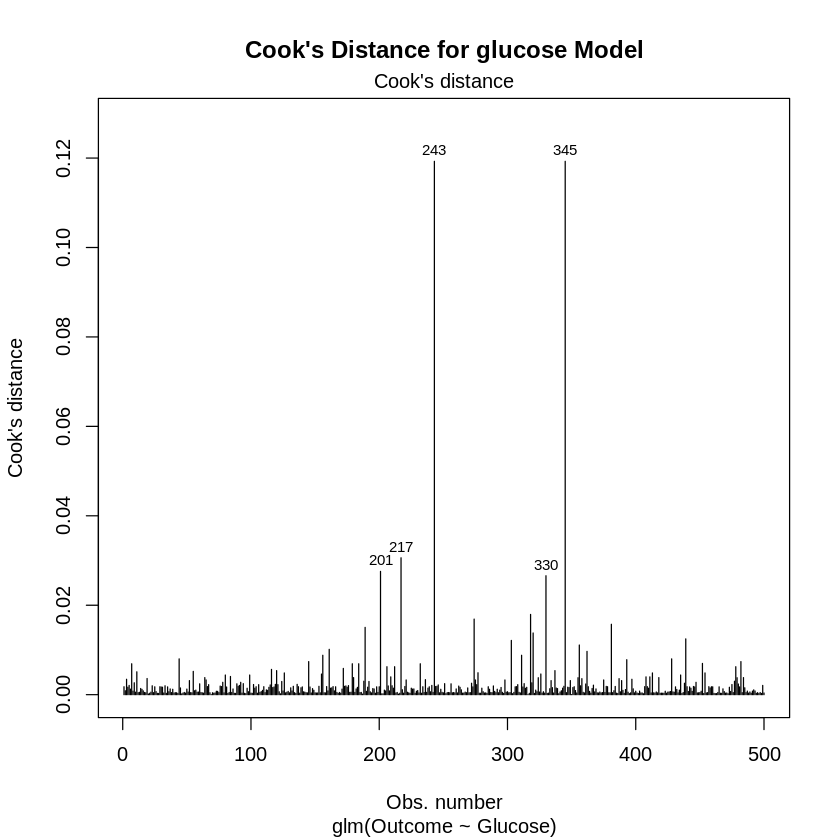

In [23]:

cooks_d <- cooks.distance(model_glucose)

plot(model_glucose,
     which = 4,
     id.n = 5,
     main = "Cook's Distance for glucose Model")


sample_size <- nrow(model_data)
threshold <- 4 / sample_size


influential_points <- which(cooks_d > threshold)

cat("Row indices of highly influential points based on the threshold:\n")
print(influential_points)

1.- It quantifies how much the regression model would change if that specific observation was excluded from the dataset.

2.- A large Cook's Distance implies that the observation has a high influence. This means that removing this single data point would cause a significant shift or distortion in the model's parameters (beta).

3.- Not always, but they need to be investigated. If an influential point is simply due to a data entry error, it should be removed. However, if it represents a legitimate, extreme case within the true population, removing it can bias the model and artificially hide natural variance.

## Q12: Run Model calibration for your model and data (do not attempt, for next assingment))
1. What does calibration mean in logistic regression?

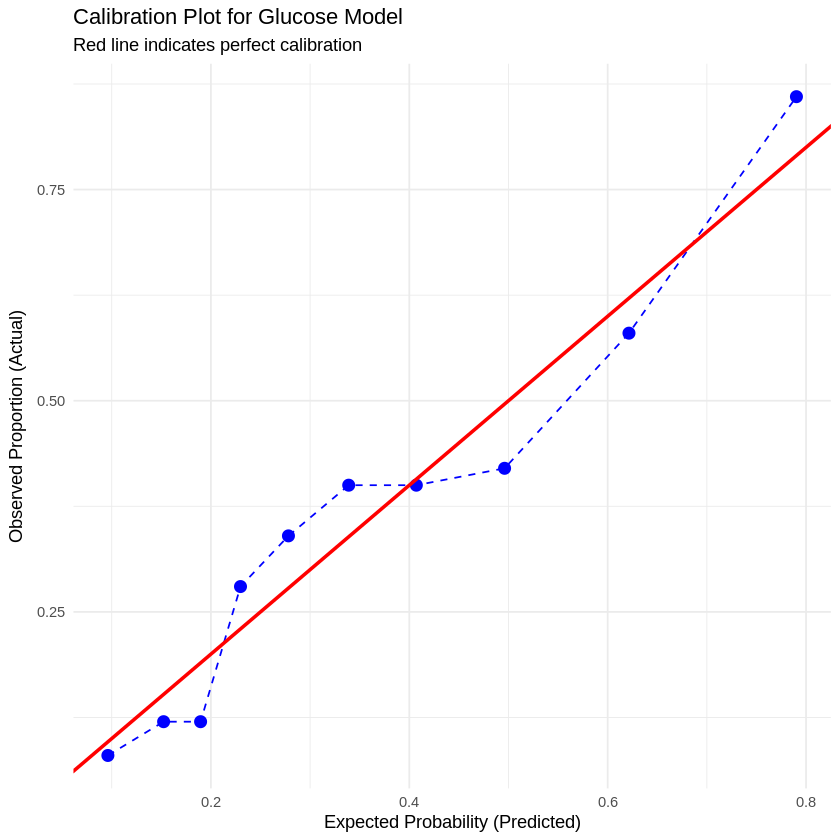

In [24]:
model_data <- model_data %>%
  mutate(predicted_prob_glucose = predict(model_glucose, type = "response"))

calib_data <- model_data %>%
  mutate(Decile = ntile(predicted_prob_glucose, 10)) %>%
  group_by(Decile) %>%
  summarise(
    Observed_Rate = mean(Outcome),
    Expected_Rate = mean(predicted_prob_glucose)
  )

ggplot(calib_data, aes(x = Expected_Rate, y = Observed_Rate)) +
  geom_point(color = "blue", size = 3) +
  geom_line(color = "blue", linetype = "dashed") +
  geom_abline(intercept = 0, slope = 1, color = "red", linewidth = 1) +
  labs(title = "Calibration Plot for Glucose Model",
       subtitle = "Red line indicates perfect calibration",
       x = "Expected Probability (Predicted)",
       y = "Observed Proportion (Actual)") +
  theme_minimal()

1.- Calibration refers to how closely the predicted probabilities from the model align with the actual observed outcomes. Essentially measures the reliability and accuracy of the model's absolute risk estimates, rather than just its ability to rank higher above lower risk.

### Q13: Final interpretation
Based on your analysis:
1. Which variable has the highest odds ratio for predicting diabetes?
2. Write down statistical interpretation of this odds ratio.  
Points: 10

1.- BMI has the highest odds ratio OR = 1.097 based on the R output.

2.- For every one-unit increase in BMI, the odds of a patient testing positive for diabetes increase 1.097 times. Because the p-value is highly significant (p < 0.001), we have strong evidence that this positive relationship between higher BMI and increased odds of diabetes is not due to random chance.

## Bonus Question:
Manully code IRLS method to fit your logistic regression and compare the results with results from `glm()` function

In [25]:

y <- model_data$Outcome

X <- cbind(1, model_data$BMI)


beta <- matrix(0, nrow = ncol(X), ncol = 1)
tolerance <- 1e-6
max_iter <- 25
diff <- 1

for (i in 1:max_iter) {

  eta <- X %*% beta


  p <- 1 / (1 + exp(-eta))


  p <- pmax(pmin(p, 1 - 1e-10), 1e-10)


  W <- diag(as.vector(p * (1 - p)))


  z <- eta + (y - p) / (p * (1 - p))


  beta_new <- solve(t(X) %*% W %*% X) %*% t(X) %*% W %*% z


  diff <- max(abs(beta_new - beta))
  beta <- beta_new

  if (diff < tolerance) {
    cat("IRLS algorithm converged in", i, "iterations.\n")
    break
  }
}


cat("\n--- Manual IRLS Coefficients ---\n")
cat("Intercept:", beta[1], "\n")
cat("BMI:      ", beta[2], "\n")

cat("\n--- Official glm() Coefficients ---\n")
cat("Intercept:", coef(model_bmi)[1], "\n")
cat("BMI:      ", coef(model_bmi)[2], "\n")


all.equal(as.vector(beta), as.vector(coef(model_bmi)), tolerance = 1e-5)

IRLS algorithm converged in 5 iterations.

--- Manual IRLS Coefficients ---
Intercept: -3.583802 
BMI:       0.09239871 

--- Official glm() Coefficients ---
Intercept: -3.583802 
BMI:       0.09239871 


[1] TRUE